<a href="https://colab.research.google.com/github/Gargeesharmaa/Machine_Learning_Models/blob/main/BigMartPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


In [30]:
# Load the dataset directly into a Pandas DataFrame
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "brijbhushannanda1979/bigmart-sales-data",
  path="Train.csv" # Assuming 'Train.csv' is the file you want to load
)

Using Colab cache for faster access to the 'bigmart-sales-data' dataset.


In [33]:
df.head()
df.shape


(8523, 12)

In [34]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [35]:
# categorical values: Item_Identifier  Item_Fat_Content   Item_Type  Outlet_Identifier  Outlet_Size  Outlet_Location_Type   Outlet_Type

In [38]:
df['Item_Weight'].mean()
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

/tmp/ipykernel_537/1472205482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)


In [39]:
mode_OutletSize = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))

In [40]:
print(mode_OutletSize)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [41]:
missing_value = df['Outlet_Size'].isnull()

In [60]:
df.loc[missing_value, 'Outlet_Size'] = df.loc[missing_value, 'Outlet_Type'].apply(lambda x: mode_OutletSize[x].Outlet_Size)

In [43]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [44]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [45]:
sns.set()

/tmp/ipykernel_537/862611423.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Weight'])


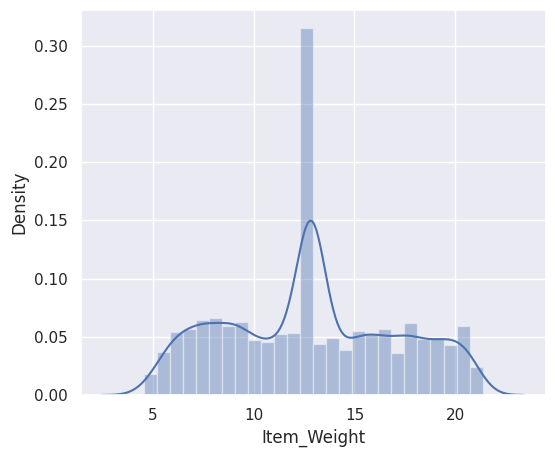

In [47]:
plt.figure(figsize=(6,5))
sns.distplot(df['Item_Weight'])
plt.show()


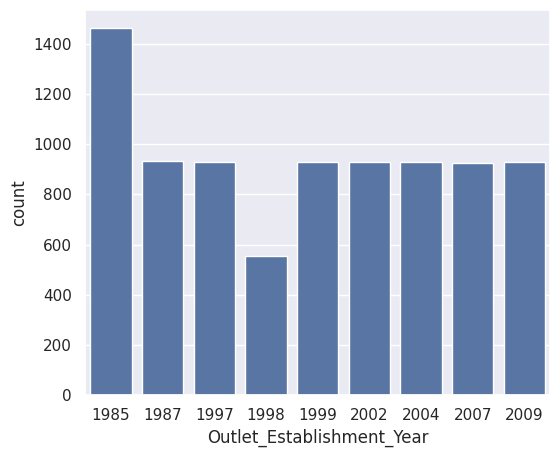

In [49]:
plt.figure(figsize=(6,5))
sns.countplot(x='Outlet_Establishment_Year', data=df)
plt.show()

In [50]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [51]:
df.replace({'Item_Fat_Content' : { 'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}}, inplace=True)

In [52]:
encoder = LabelEncoder()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   int64  
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   int64  
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  IItem_Type                 8523 non-null   int64  
dtypes: float64(4), int64(5), object(4)
memory usage:

In [61]:
df['Outlet_Size']

,Outlet_Size
0,Medium
1,Medium
2,Medium
3,Small
4,High
...,...
8518,High
8519,Small
8520,Small
8521,Medium


In [62]:
# categorical values: Item_Identifier  Item_Fat_Content   Item_Type Outlet_Identifier  Outlet_Size  Outlet_Location_Type   Outlet_Type
df['Item_Identifier'] = encoder.fit_transform(df['Item_Identifier'])
df['Item_Fat_Content'] = encoder.fit_transform(df['Item_Fat_Content'])
df['Item_Type'] = encoder.fit_transform(df['Item_Type'])
df['Outlet_Identifier'] = encoder.fit_transform(df['Outlet_Identifier'])
df['Outlet_Size'] = encoder.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = encoder.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type'] = encoder.fit_transform(df['Outlet_Type'])

In [63]:
x = df.drop(columns='Item_Outlet_Sales', axis=1)
Y =df['Item_Outlet_Sales']

In [83]:
X_train, X_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.1, random_state=54)

In [65]:
regressor = XGBRegressor()

In [84]:
regressor.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
prediction_train = regressor.predict(X_train)

In [86]:
r2_train = metrics.r2_score(Y_train, prediction_train)

In [87]:
print(r2_train)

0.8638046425834328


In [88]:
prediction_test = regressor.predict(X_test)

In [89]:
r2_test = metrics.r2_score(Y_test, prediction_test)

In [90]:
r2_test

0.5344836625252086

### Hyperparameter Tuning for XGBoost Regressor
To address the overfitting and improve the model's generalization, we will perform hyperparameter tuning using `GridSearchCV`.

In [91]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=54), # Pass random_state for reproducibility
    param_grid=param_grid,
    scoring='r2', # Use R-squared as the scoring metric
    cv=3,         # Use 3-fold cross-validation
    n_jobs=-1,    # Use all available CPU cores
    verbose=2     # Display progress messages
)

# Fit the grid search to the data
grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [92]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R2 Score (Cross-validation): {grid_search.best_score_}")

# Get the best model found by GridSearchCV
best_regressor = grid_search.best_estimator_

# Evaluate the best model on the training set
prediction_train_tuned = best_regressor.predict(X_train)
r2_train_tuned = metrics.r2_score(Y_train, prediction_train_tuned)
print(f"R2 Score (Train, Tuned Model): {r2_train_tuned}")

# Evaluate the best model on the test set
prediction_test_tuned = best_regressor.predict(X_test)
r2_test_tuned = metrics.r2_score(Y_test, prediction_test_tuned)
print(f"R2 Score (Test, Tuned Model): {r2_test_tuned}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best R2 Score (Cross-validation): 0.5967190783171059
R2 Score (Train, Tuned Model): 0.627572809870117
R2 Score (Test, Tuned Model): 0.6045771432678988


### More Extensive Hyperparameter Tuning with RandomizedSearchCV
To further optimize the XGBoost Regressor and potentially achieve higher R2 scores, we will use `RandomizedSearchCV` to explore a wider range of hyperparameters more efficiently.

In [94]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define a wider and more varied parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 1000),      # Number of boosting rounds (100 to 1000)
    'max_depth': randint(3, 10),            # Maximum depth of a tree (3 to 9)
    'learning_rate': uniform(0.01, 0.2),    # Step size shrinkage (0.01 to 0.21)
    'subsample': uniform(0.6, 0.4),         # Subsample ratio of the training instance (0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4)   # Subsample ratio of columns when constructing each tree (0.6 to 1.0)
}

# Initialize the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=54), # Pass random_state for reproducibility
    param_distributions=param_distributions,
    n_iter=50,                              # Number of parameter settings that are sampled (can be increased if more time available)
    scoring='r2',                           # Use R-squared as the scoring metric
    cv=5,                                   # Use 5-fold cross-validation
    random_state=54,                        # For reproducibility of results
    n_jobs=-1,                              # Use all available CPU cores
    verbose=2                               # Display progress messages
)

# Fit the random search to the data
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b18d7076cf0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b18d70772f0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b18d7075df0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b18d7075040>},
                   random_state=54, scoring='r2', verbose=2)

In [95]:
print(f"Best Parameters (Random Search): {random_search.best_params_}")
print(f"Best R2 Score (Random Search Cross-validation): {random_search.best_score_}")

# Get the best model found by RandomizedSearchCV
best_regressor_rand = random_search.best_estimator_

# Evaluate the best model from random search on the training set
prediction_train_rand = best_regressor_rand.predict(X_train)
r2_train_rand = metrics.r2_score(Y_train, prediction_train_rand)
print(f"R2 Score (Train, Randomized Tuned Model): {r2_train_rand}")

# Evaluate the best model from random search on the test set
prediction_test_rand = best_regressor_rand.predict(X_test)
r2_test_rand = metrics.r2_score(Y_test, prediction_test_rand)
print(f"R2 Score (Test, Randomized Tuned Model): {r2_test_rand}")

Best Parameters (Random Search): {'colsample_bytree': np.float64(0.7231882300419066), 'learning_rate': np.float64(0.03205556046326389), 'max_depth': 4, 'n_estimators': 201, 'subsample': np.float64(0.9672817587393209)}
Best R2 Score (Random Search Cross-validation): 0.5980660476085207
R2 Score (Train, Randomized Tuned Model): 0.63335935679077
R2 Score (Test, Randomized Tuned Model): 0.5945455606664775


### Visualizing Actual vs. Predicted Sales
Let's visualize the performance of our best model from `RandomizedSearchCV` by plotting the actual sales against the predicted sales for the test set. This will help us understand where the model is performing well and where there might be systematic errors.

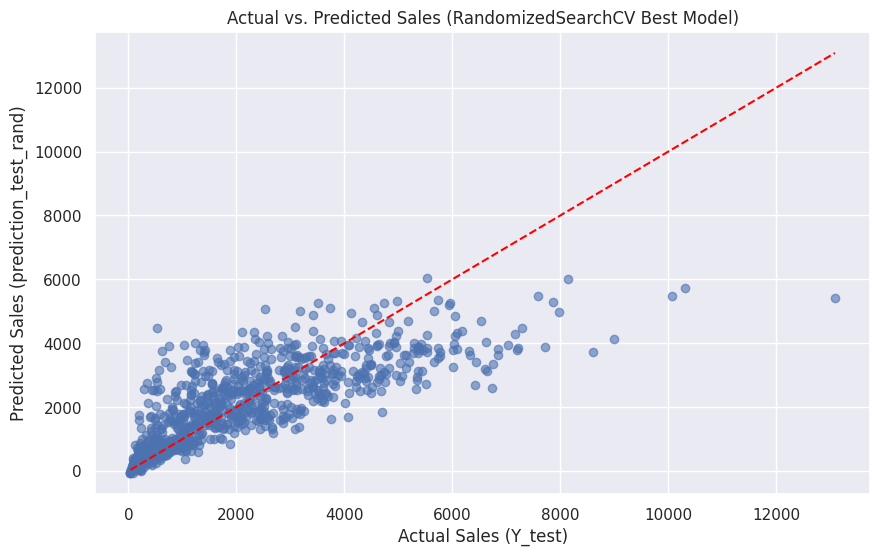

In [96]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, prediction_test_rand, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--') # Ideal line
plt.title('Actual vs. Predicted Sales (RandomizedSearchCV Best Model)')
plt.xlabel('Actual Sales (Y_test)')
plt.ylabel('Predicted Sales (prediction_test_rand)')
plt.grid(True)
plt.show()